# Session 7, Notebook 2: SMM with Two Parameters

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 10:05-11:00, Structural estimation via the simulated method of moments
**Slides:** `07_Structural_Estimation_SMM.pdf`
**Author:** Simon Scheidegger (HEC, University of Lausanne)

In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0

Same model, same workflow as Notebook 1, with the discount factor $\beta$ and the persistence
$\varrho$ estimated **jointly**. Two things change: the surrogate takes both parameters as inputs, and
the criterion is a surface rather than a curve. The surface is where the lesson sits: how sharply
each moment set pins down $\beta$. The dynamic moments respond to $\beta$ only weakly; the mean
investment share, a level moment, responds to it directly, and adding it makes the criterion about
twenty times more curved along $\beta$. Both statements are measured below.

| Section | Step |
|:--|:--|
| 1 | The data at $(\beta, \varrho) = (0.96, 0.90)$ |
| 2 | The surrogate with two pseudo-states |
| 3 | Its accuracy against the reference solution at five parameter pairs |
| 4 | Two criterion surfaces: dynamic moments only, and with the level moment |
| 5 | The joint estimate, and the moment Jacobian as the identification diagnostic |

In [2]:
# ----------------------------------------------------------------
# Imports, presets, plot style, the reference solver
# ----------------------------------------------------------------
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import minimize
import torch
import torch.nn as nn

sys.path.insert(0, "..")
import brock_mirman_reference as bm

torch.set_num_threads(2)
torch.manual_seed(SEED)
np.random.seed(SEED)

rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                 "legend.fontsize": 10, "font.family": "serif", "mathtext.fontset": "cm",
                 "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_REF, C_SUR, C_DATA = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = (RUN_MODE == "teaching")
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")

N_STEPS = {"smoke": 3000, "teaching": 30000, "production": 80000}[RUN_MODE]
T_DATA  = 500
T_SIM   = {"smoke": 1000, "teaching": 2000, "production": 4000}[RUN_MODE]
N_GRID  = {"smoke": (15, 15), "teaching": (29, 50), "production": (36, 99)}[RUN_MODE]   # (beta, rho) grid
T_NOTEBOOK = time.perf_counter()
print(f"RUN_MODE = {RUN_MODE}: {N_STEPS} training steps, {N_GRID[0]} x {N_GRID[1]} criterion grid")

RUN_MODE = teaching: 30000 training steps, 29 x 50 criterion grid


---
## 1. The data

One path of length 500 from the reference solution at $(\beta, \varrho) = (0.96, 0.90)$, with its own
shocks. All four moments are kept: the mean investment share is now an identifying moment, not a
diagnostic, because it is the one that responds to $\beta$.

In [3]:
BETA_TRUE, RHO_TRUE = 0.96, 0.90
BETA_LO, BETA_HI = 0.92, 0.99
RHO_LO, RHO_HI = 0.50, 0.99

policy_true = bm.solve(BETA_TRUE, RHO_TRUE)
Y_data, C_data, K_data = bm.simulate(policy_true, BETA_TRUE, RHO_TRUE, T=T_DATA, seed=12)
m_data = bm.moments(Y_data, C_data, K_data)
DYNAMIC = np.array([True, True, True, False])      # the three dynamic moments
ALL     = np.array([True, True, True, True])       # plus the level moment

print(f"observed sample: T = {T_DATA}")
for name, v in zip(bm.MOMENT_NAMES, m_data):
    print(f"  {name:<20s} {v:+.5f}")
print(f"\nsteady-state capital: {bm.steady_state(BETA_LO)[0]:.2f} at beta = {BETA_LO}, "
      f"{bm.steady_state(BETA_HI)[0]:.2f} at beta = {BETA_HI}: the level moment is what beta moves")

observed sample: T = 500
  Std(dlog C)          +0.02049
  Autocorr(dlog C)     +0.31090
  Autocorr(log Y)      +0.94102
  Mean savings rate    +0.25347

steady-state capital: 2.78 at beta = 0.92, 6.37 at beta = 0.99: the level moment is what beta moves


---
## 2. The surrogate with two pseudo-states

The network ($2 \times 128$, tanh) maps $(\log z, \log K, \beta, \varrho)$ to the consumption share of cash on hand. The Euler
residual is the same as before with $\beta$ read from the input instead of a constant. Capital is
scaled by the steady-state capital at $\beta = 0.96$; the box for $K$ is wide enough to cover the
ergodic sets of every $\beta$ in the range.

In [4]:
Z_SD_MAX = bm.SIGMA / np.sqrt(1.0 - RHO_HI**2)
LOGZ_LIM = 4.0 * Z_SD_MAX
K_LO, K_HI = 0.5, 24.0
K_STAR = bm.steady_state(BETA_TRUE)[0]
GH_X = torch.tensor(bm.GH_NODES, dtype=torch.float32); GH_W = torch.tensor(bm.GH_WEIGHTS, dtype=torch.float32)


class PolicyNet(nn.Module):
    """(log z, K, beta, rho) -> consumption share of cash on hand, in (0, 1)."""
    def __init__(self, width=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4, width), nn.Tanh(), nn.Linear(width, width), nn.Tanh(),
                                 nn.Linear(width, 1))
    def forward(self, logz, K, beta, rho):
        x = torch.stack([logz / LOGZ_LIM, torch.log(K / K_STAR), (beta - 0.955) / 0.035, (rho - 0.745) / 0.245], dim=-1)
        return torch.sigmoid(self.net(x)).squeeze(-1)


def step_economy(net, logz, K, beta, rho):
    z = torch.exp(logz)
    m = z * K**bm.ALPHA + (1.0 - bm.DELTA) * K
    C = net(logz, K, beta, rho) * m
    return C, m - C, m


def euler_residual(net, logz, K, beta, rho):
    C, K1, _ = step_economy(net, logz, K, beta, rho)
    rhs = torch.zeros_like(C)
    for x, w in zip(GH_X, GH_W):
        logz1 = rho * logz + bm.SIGMA * x
        C1, _, _ = step_economy(net, logz1, K1, beta, rho)
        rhs = rhs + w * (1.0 - bm.DELTA + bm.ALPHA * torch.exp(logz1) * K1**(bm.ALPHA - 1.0)) / C1
    return 1.0 - 1.0 / (beta * C * rhs)


def sample_box(n):
    return (torch.empty(n).uniform_(-LOGZ_LIM, LOGZ_LIM), torch.empty(n).uniform_(K_LO, K_HI),
            torch.empty(n).uniform_(BETA_LO, BETA_HI), torch.empty(n).uniform_(RHO_LO, RHO_HI))


net = PolicyNet()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_STEPS, eta_min=1e-5)
BATCH = 256
logz_sim, K_sim, beta_sim, rho_sim = sample_box(BATCH // 2)

t0, losses = time.perf_counter(), []
for step in range(1, N_STEPS + 1):
    with torch.no_grad():
        _, K_sim, _ = step_economy(net, logz_sim, K_sim, beta_sim, rho_sim)
        logz_sim = rho_sim * logz_sim + bm.SIGMA * torch.randn(BATCH // 2)
        K_sim = K_sim.clamp(K_LO, K_HI)
    lb, kb, bb, rb = sample_box(BATCH // 2)
    args = (torch.cat([lb, logz_sim]), torch.cat([kb, K_sim]), torch.cat([bb, beta_sim]), torch.cat([rb, rho_sim]))
    loss = torch.mean(euler_residual(net, *args)**2)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses.append(loss.item())
    if step % (N_STEPS // 5) == 0:
        print(f"step {step:>6d}  mean squared Euler residual {np.mean(losses[-100:]):.2e}")
print(f"trained in {time.perf_counter()-t0:.0f} s; {sum(p.numel() for p in net.parameters())} parameters")


def surrogate_consumption(logz, K, beta, rho):
    with torch.no_grad():
        C, _, _ = step_economy(net, *(torch.as_tensor(np.asarray(a, np.float32)) for a in np.broadcast_arrays(logz, K, beta, rho)))
    return C.numpy()

step   6000  mean squared Euler residual 8.94e-07


step  12000  mean squared Euler residual 4.94e-07


step  18000  mean squared Euler residual 1.95e-07


step  24000  mean squared Euler residual 7.64e-08


step  30000  mean squared Euler residual 5.06e-08
trained in 216 s; 17281 parameters


---
## 3. Accuracy against the reference solution

The same two numbers as in Notebook 1, at five parameter pairs that span the box, on 2,000 states
from each pair's ergodic set.

In [5]:
PAIRS = [(0.92, 0.50), (0.92, 0.99), (0.96, 0.90), (0.99, 0.50), (0.99, 0.99)]
acc = []
for beta, rho in PAIRS:
    pol = bm.solve(beta, rho)
    Y, C, K = bm.simulate(pol, beta, rho, T=2000, seed=7)
    logz = np.log(Y / K**bm.ALPHA)
    C_net = surrogate_consumption(logz, K, beta, rho)
    ee = euler_residual(net, *(torch.as_tensor(np.asarray(a, np.float32)) for a in (logz, K, np.full_like(K, beta), np.full_like(K, rho)))).detach().numpy()
    rel = np.abs(C_net - C) / C
    acc.append((beta, rho, np.abs(ee).mean(), np.abs(ee).max(), rel.mean(), rel.max()))

print(f"{'beta':>5s} {'rho':>5s} {'mean |Euler|':>13s} {'max |Euler|':>12s} {'mean |dC|/C':>12s} {'max |dC|/C':>11s}")
for r in acc:
    print(f"{r[0]:>5.2f} {r[1]:>5.2f} {r[2]:>13.1e} {r[3]:>12.1e} {r[4]:>12.1e} {r[5]:>11.1e}")

 beta   rho  mean |Euler|  max |Euler|  mean |dC|/C  max |dC|/C
 0.92  0.50       1.3e-04      3.5e-04      4.2e-04     7.6e-04
 0.92  0.99       1.8e-04      1.1e-03      5.9e-04     3.0e-03
 0.96  0.90       3.1e-05      1.9e-04      9.8e-05     5.3e-04
 0.99  0.50       3.0e-04      4.4e-04      2.3e-03     2.9e-03
 0.99  0.99       5.3e-04      5.1e-03      3.7e-03     3.3e-02


---
## 4. Two criterion surfaces

Every grid point $(\beta, \varrho)$ is simulated under the same shocks. The criterion is computed
twice: with the three dynamic moments, and with all four. To compare how sharply each set pins down
$\beta$, the **profiled criterion** $\min_\varrho Q(\beta, \varrho)$ follows the floor of each
surface across $\beta$.

1450 candidates simulated in 3 s


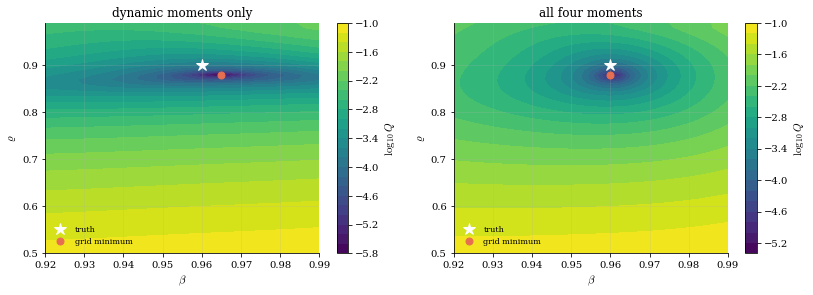

  beta   dynamic only     all four   (min over rho of Q)
 0.920       3.40e-04     4.22e-03
 0.960       5.64e-06     6.20e-06
 0.990       1.44e-04     5.26e-03
dynamic moments only: profiled criterion spans a factor 208 across the beta range
all four moments: profiled criterion spans a factor 849 across the beta range


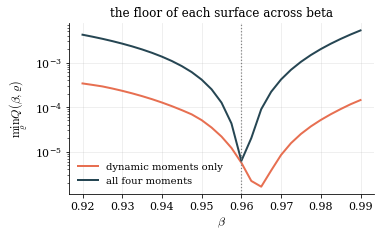

In [6]:
def simulate_paths(consumption, theta, T, seed, burn=200, K0=K_STAR):
    theta = np.atleast_2d(np.asarray(theta, float))
    beta, rho = theta[:, 0], theta[:, 1]
    eps = np.random.default_rng(seed).standard_normal(T + burn)
    logz, K = np.zeros_like(rho), np.full_like(rho, K0)
    Y_out, C_out, K_out = [], [], []
    for t in range(T + burn):
        Y = np.exp(logz) * K**bm.ALPHA
        C = consumption(logz, K, beta, rho)
        if t >= burn:
            Y_out.append(Y); C_out.append(C); K_out.append(K)
        K = Y + (1.0 - bm.DELTA) * K - C
        logz = rho * logz + bm.SIGMA * eps[t]
    return np.array(Y_out), np.array(C_out), np.array(K_out)


def moments_surrogate(theta, seed=SEED + 1):
    return np.atleast_2d(bm.moments(*simulate_paths(surrogate_consumption, theta, T_SIM, seed)))


def criterion(theta, mask, moments_fn=moments_surrogate):
    d = moments_fn(theta)[:, mask] - m_data[mask]
    return np.sum(d * d, axis=1)


beta_grid = np.linspace(BETA_LO, BETA_HI, N_GRID[0])
rho_grid  = np.linspace(RHO_LO, RHO_HI, N_GRID[1])
BB, RR = np.meshgrid(beta_grid, rho_grid)
theta_grid = np.column_stack([BB.ravel(), RR.ravel()])
t0 = time.perf_counter()
M_grid = moments_surrogate(theta_grid)
print(f"{len(theta_grid)} candidates simulated in {time.perf_counter()-t0:.0f} s")

Q = {}
for label, mask in [("dynamic moments only", DYNAMIC), ("all four moments", ALL)]:
    d = M_grid[:, mask] - m_data[mask]
    Q[label] = np.sum(d * d, axis=1).reshape(BB.shape)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, (label, Qs) in zip(axes, Q.items()):
    cs = ax.contourf(BB, RR, np.log10(Qs), levels=24, cmap="viridis")
    i = np.unravel_index(np.argmin(Qs), Qs.shape)
    ax.plot(BETA_TRUE, RHO_TRUE, "*", color="white", ms=12, label="truth")
    ax.plot(BB[i], RR[i], "o", color=C_SUR, ms=7, label="grid minimum")
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$"); ax.set_title(label); ax.legend(frameon=False, fontsize=8, loc="lower left")
    plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q$")
fig.tight_layout(); savefig(fig, "smm2_criterion_surfaces"); plt.show()

# The profiled criterion: for each beta, the smallest Q over rho. The flatter it is, the more weakly beta is pinned down.
prof = {label: Qs.min(axis=0) for label, Qs in Q.items()}
print(f"{'beta':>6s} {'dynamic only':>14s} {'all four':>12s}   (min over rho of Q)")
for b in (BETA_LO, BETA_TRUE, BETA_HI):
    i = int(np.argmin(np.abs(beta_grid - b)))
    print(f"{beta_grid[i]:>6.3f} {prof['dynamic moments only'][i]:>14.2e} {prof['all four moments'][i]:>12.2e}")
for label, pr in prof.items():
    print(f"{label}: profiled criterion spans a factor {pr.max()/pr.min():.0f} across the beta range")

fig, ax = plt.subplots(figsize=(5.4, 3.4))
for (label, pr), col in zip(prof.items(), [C_SUR, C_REF]):
    ax.semilogy(beta_grid, pr, lw=2.0, color=col, label=label)
ax.axvline(BETA_TRUE, color="0.5", ls=":", lw=1.2)
ax.set_xlabel(r"$\beta$", fontsize=12); ax.set_ylabel(r"$\min_\varrho Q(\beta, \varrho)$", fontsize=12)
ax.set_title("the floor of each surface across beta", fontsize=12); ax.legend(frameon=False, fontsize=10)
ax.tick_params(labelsize=11)
fig.tight_layout(); savefig(fig, "smm2_profiled_criterion"); plt.show()

---
## 5. The joint estimate and the identification diagnostic

The estimate refines the grid minimum with a bounded quasi-Newton method, calling the surrogate
simulation at every trial point. The diagnostic is the moment Jacobian at the estimate, by central
differences on the surrogate, with the parameters scaled to the box, $u = (\theta - \theta_{\rm lo}) /
(\theta_{\rm hi} - \theta_{\rm lo})$, so that the two columns are comparable and the numbers describe the
surface as plotted: $M = \partial m / \partial u$. Near the minimum $Q \approx \delta u^\top M^\top M\, \delta u$,
so the smallest singular value of $M$ is the square root of the criterion's curvature in its flattest
direction, and the corresponding right singular vector is that direction. A small value with the
vector pointing along $\beta$ is the left surface of the previous cell, in one number.

dynamic moments only: beta_hat = 0.9641, rho_hat = 0.8786, Q = 9.27e-07
   singular values of M: 0.273, 0.0320 (ratio 9); flattest direction (-1.00, -0.01) in (beta, rho)


all four moments: beta_hat = 0.9605, rho_hat = 0.8782, Q = 3.78e-06
   singular values of M: 0.272, 0.1419 (ratio 2); flattest direction (-1.00, -0.02) in (beta, rho)
truth: beta = 0.96, rho = 0.9



moment                d m / d u_beta  d m / d u_rho   (u = parameter scaled to the box)
Std(dlog C)                  -0.0053        +0.0205
Autocorr(dlog C)             -0.0325        +0.0082
Autocorr(log Y)              -0.0028        +0.2714
Mean savings rate            +0.1381        +0.0014



moment                    data    fitted
Std(dlog C)           +0.02049  +0.01980
Autocorr(dlog C)      +0.31090  +0.31269
Autocorr(log Y)       +0.94102  +0.94100
Mean savings rate     +0.25347  +0.25377


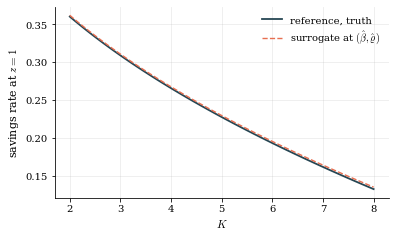

In [7]:
def estimate(mask, label):
    Qs = Q[label]
    i = np.unravel_index(np.argmin(Qs), Qs.shape)
    x0 = np.array([BB[i], RR[i]])
    res = minimize(lambda th: float(criterion(th, mask)[0]), x0, method="L-BFGS-B",
                   bounds=[(BETA_LO, BETA_HI), (RHO_LO, RHO_HI)], options={"eps": 1e-4, "ftol": 1e-12, "gtol": 1e-9})
    return res.x, res.fun

WIDTH = np.array([BETA_HI - BETA_LO, RHO_HI - RHO_LO])

def jacobian(theta, h=(0.002, 0.005)):
    """d m / d u, with u the parameters scaled to the box [0, 1]^2, by central differences."""
    cols = []
    for j in range(2):
        e = np.zeros(2); e[j] = h[j]
        cols.append((moments_surrogate(theta + e)[0] - moments_surrogate(theta - e)[0]) / (2 * h[j]) * WIDTH[j])
    return np.column_stack(cols)

results = {}
for label, mask in [("dynamic moments only", DYNAMIC), ("all four moments", ALL)]:
    theta_hat, q = estimate(mask, label)
    M = jacobian(theta_hat)[mask]
    _, sv, Vt = np.linalg.svd(M)
    results[label] = (theta_hat, q, sv, Vt[-1])
    print(f"{label}: beta_hat = {theta_hat[0]:.4f}, rho_hat = {theta_hat[1]:.4f}, Q = {q:.2e}")
    print(f"   singular values of M: {sv[0]:.3f}, {sv[1]:.4f} (ratio {sv[0]/sv[1]:.0f}); flattest direction "
          f"({Vt[-1][0]:+.2f}, {Vt[-1][1]:+.2f}) in (beta, rho)")
print(f"truth: beta = {BETA_TRUE}, rho = {RHO_TRUE}")

M_all = jacobian(results["all four moments"][0])
print(f"\n{'moment':<20s} {'d m / d u_beta':>15s} {'d m / d u_rho':>14s}   (u = parameter scaled to the box)")
for name, row in zip(bm.MOMENT_NAMES, M_all):
    print(f"{name:<20s} {row[0]:>+15.4f} {row[1]:>+14.4f}")

theta_hat = results["all four moments"][0]
m_hat = moments_surrogate(theta_hat)[0]
print(f"\n{'moment':<20s} {'data':>9s} {'fitted':>9s}")
for name, d, f in zip(bm.MOMENT_NAMES, m_data, m_hat):
    print(f"{name:<20s} {d:>+9.5f} {f:>+9.5f}")

# Policy at the estimate against the reference solution at the truth.
K_line = np.linspace(2.0, 8.0, 100)
s_true = policy_true(1.0, K_line)
m_line = bm.cash_on_hand(1.0, K_line)
s_hat = (m_line - surrogate_consumption(0.0, K_line, theta_hat[0], theta_hat[1]) - (1.0 - bm.DELTA) * K_line) / K_line**bm.ALPHA
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(K_line, s_true, color=C_REF, lw=1.8, label="reference, truth")
ax.plot(K_line, s_hat, color=C_SUR, lw=1.4, ls="--", label=rf"surrogate at $(\hat\beta, \hat\varrho)$")
ax.set_xlabel("$K$"); ax.set_ylabel("savings rate at $z = 1$"); ax.legend(frameon=False)
fig.tight_layout(); savefig(fig, "smm2_policy_match"); plt.show()

---
## 6. The other route: Gaussian processes of the moment map

As in Notebook 1: one GP per moment, fit to reference solves on a small design over the box, with
one length scale per parameter. The GP means replace the simulation in the criterion. The design
is where the cost sits: each point is one solve and one simulation.

24 reference solves and simulations in 42 s


GP route: beta_hat = 0.9604, rho_hat = 0.8785   (network route 0.9605, 0.8782; truth 0.96, 0.90)
GP posterior sd of the moments at the estimate: 5.4e-06, 7.8e-05, 1.9e-05, 4.3e-06
length scales (beta, rho) in box units per moment: 10.21, 2.69; 9.15, 2.08; 22.12, 8.32; 6.51, 75.62


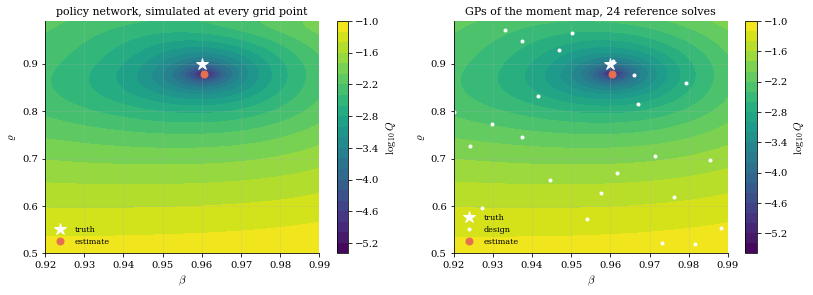

In [8]:
import warnings
from scipy.stats import qmc
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
warnings.filterwarnings("ignore", category=ConvergenceWarning)      # the optimizer's stop reports, not errors

N_DESIGN = {"smoke": 12, "teaching": 24, "production": 48}[RUN_MODE]
LO, HI = np.array([BETA_LO, RHO_LO]), np.array([BETA_HI, RHO_HI])
u = lambda th: (np.atleast_2d(th) - LO) / (HI - LO)
theta_design = qmc.scale(qmc.LatinHypercube(d=2, seed=SEED).random(N_DESIGN), LO, HI)

t0 = time.perf_counter()
m_design = []
for beta, rho in theta_design:
    pol = bm.solve(beta, rho)
    Y, C, K = simulate_paths(lambda lz, K_, b, r: pol.consumption(np.exp(lz), bm.cash_on_hand(np.exp(lz), K_)), [[beta, rho]], T_SIM, SEED + 1)
    m_design.append(bm.moments(Y, C, K))
m_design = np.array(m_design)
print(f"{N_DESIGN} reference solves and simulations in {time.perf_counter()-t0:.0f} s")

gps = [GaussianProcessRegressor(ConstantKernel(1.0) * Matern([0.3, 0.3], nu=2.5), alpha=1e-8, normalize_y=True,
                                n_restarts_optimizer=5, random_state=SEED).fit(u(theta_design), m_design[:, j]) for j in range(4)]

def moments_gp(theta, return_std=False):
    out = [gp.predict(u(theta), return_std=True) for gp in gps]
    mean = np.column_stack([o[0] for o in out]); std = np.column_stack([o[1] for o in out])
    return (mean, std) if return_std else mean

Q_gp = criterion(theta_grid, ALL, moments_gp).reshape(BB.shape)
i = np.unravel_index(np.argmin(Q_gp), Q_gp.shape)
res_gp = minimize(lambda th: float(criterion(th, ALL, moments_gp)[0]), np.array([BB[i], RR[i]]), method="L-BFGS-B",
                  bounds=[(BETA_LO, BETA_HI), (RHO_LO, RHO_HI)], options={"eps": 1e-4, "ftol": 1e-12, "gtol": 1e-9})
theta_gp = res_gp.x
_, sd_gp = moments_gp(theta_gp, return_std=True)
print(f"GP route: beta_hat = {theta_gp[0]:.4f}, rho_hat = {theta_gp[1]:.4f}   (network route {theta_hat[0]:.4f}, {theta_hat[1]:.4f}; truth 0.96, 0.90)")
print("GP posterior sd of the moments at the estimate: " + ", ".join(f"{v:.1e}" for v in sd_gp[0]))
print("length scales (beta, rho) in box units per moment: " + "; ".join(f"{gp.kernel_.k2.length_scale[0]:.2f}, {gp.kernel_.k2.length_scale[1]:.2f}" for gp in gps))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, Qs, title in [(axes[0], Q["all four moments"], "policy network, simulated at every grid point"),
                      (axes[1], Q_gp, f"GPs of the moment map, {N_DESIGN} reference solves")]:
    cs = ax.contourf(BB, RR, np.log10(Qs), levels=24, cmap="viridis")
    ax.plot(BETA_TRUE, RHO_TRUE, "*", color="white", ms=12, label="truth")
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$"); ax.set_title(title, fontsize=11)
    plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q$")
axes[0].plot(theta_hat[0], theta_hat[1], "o", color=C_SUR, ms=7, label="estimate")
axes[1].plot(theta_design[:, 0], theta_design[:, 1], "o", color="white", ms=3, label="design")
axes[1].plot(theta_gp[0], theta_gp[1], "o", color=C_SUR, ms=7, label="estimate")
for ax in axes:
    ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout(); savefig(fig, "smm2_gp_route"); plt.show()

## 7. What to remember

1. **Two parameters cost nothing extra.** The surrogate has one more input; the estimation loop is
   the same simulation and the same criterion. The reference solver would have needed one solve per
   grid point.
2. **Identification is a property of the moments.** The dynamic moments pin $\beta$ down weakly:
   the floor of their criterion rises far less steeply along $\beta$ than with the level moment
   added, and a small error in the moments moves the estimate far along $\beta$. A level moment
   that $\beta$ moves directly fixes that.
3. **The Jacobian says it in one number.** The smallest singular value of $\partial m / \partial u$
   is the square root of the criterion's curvature in its flattest direction, and the singular vector
   names that direction. Both come free from the surrogate, and they agree with the surfaces.
4. **A flat direction can also be the surrogate's fault.** If the network barely responds to a
   parameter, the criterion is flat in it whatever the moments. Section 3 rules that out here: the
   consumption error against the reference solution is small at every corner of the box.
5. **The GP route scales with the number of solves, the network route with training.** With two
   parameters the GP needs a two-dimensional design; each added parameter multiplies the solves it
   needs, while the policy network adds one input. Section 6 shows where the two agree.

In [9]:
theta_all = results["all four moments"][0]
ok = (BETA_LO < theta_all[0] < BETA_HI and RHO_LO < theta_all[1] < RHO_HI
      and abs(theta_all[0] - BETA_TRUE) < 0.01 and abs(theta_all[1] - RHO_TRUE) < 0.03
      and all(r[4] < 5e-3 for r in acc))
print(("PASS" if ok else "CHECK") + f": beta_hat = {theta_all[0]:.4f}, rho_hat = {theta_all[1]:.4f}, "
      f"max mean consumption error {max(r[4] for r in acc):.1e}")
print(f"RUN_MODE = {RUN_MODE}; notebook wall-clock {time.perf_counter()-T_NOTEBOOK:.0f} s")

PASS: beta_hat = 0.9605, rho_hat = 0.8782, max mean consumption error 3.7e-03
RUN_MODE = teaching; notebook wall-clock 466 s
